# Per-leg Photo Selection

This notebook is a copy of the old `04_leg_selection.ipynb` with one improvement:
instead of building a road buffer only from the **directly connected** wegvakken
(which are sometimes too short near complex junctions), the buffer for each leg
is built by **chaining segments outward** along the leg's bearing direction until
the corridor is at least `MAX_DIST` long.

At each intermediate junction the next segment is chosen as the one whose travel
bearing deviates least from the current direction (within `BEARING_CHAIN_TOLERANCE`
degrees). The bearing is updated after each hop so gradual road curves are followed
naturally.

**Input files:**
- `data/processed/selected_photos_near_intersections.csv` — filtered photo list (from notebook 02)
- `data/processed/intersections_stratified.gpkg` — intersections with stratum labels (from notebook 03)
- `data/processed/wegvakken_rotterdam_bst_merged.gpkg` — NWB road segments with merged junction IDs (from notebook 01)
- `D:\rotterdam_aiis_2025\vault-production\vault_v1\Recording.csv` — needed for Pan angles (tab-delimited)
- `data/processed/intensiteiten_rotterdam.csv` — Rotterdam-only intensity cache (from notebook 03, optional)

**Output files:**
- `data/processed/leg_photo_selection.csv` — one row per leg, best-matched photo only; feeds into notebooks 05, 06, and 07. Includes `intensity_wvk` (vehicles/day on the approach segment), `WVK_ID`, and `neighbor_jte_id` when `USE_INTENSITY=True`.
- `data/processed/leg_photo_candidates.csv` — top-N ranked candidate photos per leg; feeds into `util_photo_export_list` for CV training export

**Depends on:** notebooks 00, 01, 02 and 03 must be run first.

**Coordinate system:** RD New (EPSG:28992) — NWB is already in this projection, no reprojection needed.

In [ ]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import os

# Base project directory
PROJECT_DIR = r"C:\Users\Thijs\OneDrive\Documents\Studie\EPA\Second year\Afstuderen\Project\intersections"

# Input: selected photos from notebook 02.
# Already contains Filename, filepath, X/Long, Y/Lat, Pan, Timestamp — and for TU Delft 2024
# also the per-direction columns (img_front/back/left/right, heading_*).
# Notebook 02 handles all dataset-specific normalisation, so this notebook is dataset-agnostic.
SELECTED_CSV = os.path.join(PROJECT_DIR, "data", "processed", "selected_photos_near_intersections.csv")

# Input: NWB road segments with merged junction IDs - output of notebook 01.
# Already filtered to Rotterdam gemeente-managed roads + BST_CODE types (RB/ERF/HR).
WEGVAKKEN_PATH = os.path.join(PROJECT_DIR, "data", "processed", "wegvakken_rotterdam_bst_merged.gpkg")

# Input: unfiltered Rotterdam gemeente roads — used only for debug visualisation.
WEGVAKKEN_UNFILTERED_PATH = os.path.join(PROJECT_DIR, "data", "processed", "wegvakken_rotterdam.gpkg")

# Input: stratified intersections (notebook 03 output); falls back to merged file (notebook 01).
_stratified = os.path.join(PROJECT_DIR, "data", "processed", "intersections_stratified.gpkg")
_fallback   = os.path.join(PROJECT_DIR, "data", "processed", "intersections_merged.gpkg")
INTERSECTIONS_PATH = _stratified if os.path.exists(_stratified) else _fallback
print(f"Using intersections file: {os.path.basename(INTERSECTIONS_PATH)}")

# Input: Rotterdam-only intensity cache (from notebook 03, USE_INTENSITY=True).
INTENSITY_ROT_FILE = os.path.join(PROJECT_DIR, "data", "processed", "intensiteiten_rotterdam.csv")

# Output: one row per leg — the single best-matched photo per leg.
OUTPUT_CSV = os.path.join(PROJECT_DIR, "data", "processed", "leg_photo_selection.csv")

# Output: top-N candidate photos per leg — for CV training export.
CANDIDATES_CSV = os.path.join(PROJECT_DIR, "data", "processed", "leg_photo_candidates.csv")

# Output: directional image files that were selected but not found on disk.
# Use this CSV to identify and copy the missing files to the HDD separately.
MISSING_FILES_CSV = os.path.join(PROJECT_DIR, "data", "processed", "missing_images.csv")

# Vault root — used to build full absolute paths for TU Delft 2024 directional images.
# Notebook 02 exports relative paths for img_back/left/right; this prefix completes them.
VAULT_DIR = r"D:\rotterdam_aiis_2025\vault-production\vault_v1"

# 360° panoramas directory — when Francisco adds full equirectangular panoramas,
# place them here flat as {image_id}.jpg (e.g. 1_00001.jpg).
# If a panorama file is found for a camera location, the old u_deg equirectangular
# rotation logic is used instead of directional image selection.
PANORAMA_DIR = os.path.join(VAULT_DIR, "panoramas")

# Distance range for photo selection (metres from intersection)
MIN_DIST = 5
MAX_DIST = 55

# How far a photo may be from the wegvak centreline and still count as "on that road".
ROAD_BUFFER_M = 3

# Maximum angular deviation (degrees) when chaining the next road segment outward.
BEARING_CHAIN_TOLERANCE = 45

# Half-width of the visualisation window around each intersection (metres)
VIZ_RADIUS = 80

# Per-intersection capture and ideal shot distances (computed in notebook 01).
CAPTURE_BUFFER_M   = 30
IDEAL_PHOTO_BUFFER = 30
IDEAL_PHOTO_DIST   = 30  # legacy fallback if ideal_dist_m column missing

# Number of ranked candidate photos to keep per leg in the CV export list.
TOP_N_CANDIDATES = 3

# Toggle: add intensity_wvk (vehicles/day) per approach leg from the Fileradar cache.
USE_INTENSITY = True

# --- Testing mode ---
# Set to a number (e.g. 50) to only process that many intersections — faster for testing.
# Set to None to process all intersections.
N_INTERSECTIONS = None

# Assumed horizontal field-of-view per directional camera (degrees).
# TU Delft 2024 cameras are exactly 90° apart — exp_image_stitching confirmed no seam.
FOV_H = 90

# Stitch two adjacent cameras when the intersection falls more than this many degrees
# off-center in the single best camera view. Below this threshold, single-camera is fine.
STITCH_THRESHOLD = 30  # degrees

CRS_RD = "EPSG:28992"

## 1. Load selected photos and their Pan angles

In [ ]:
# Load the selected photos CSV (output of notebook 02).
# Pan is already included — notebook 02 normalises it from the source dataset
# (heading_front for TU Delft 2024, real Pan for legacy AIIS), so no separate
# recording file needs to be loaded here.
selected = pd.read_csv(SELECTED_CSV)
print(f"Selected photos loaded: {len(selected):,}")
print(f"Photos with Pan angle: {selected['Pan'].notna().sum():,}")

# Convert to GeoDataFrame using RD New coordinates
photos_gdf = gpd.GeoDataFrame(
    selected,
    geometry=gpd.points_from_xy(selected["X/Long"], selected["Y/Lat"]),
    crs=CRS_RD
)

photos_gdf[["Filename", "X/Long", "Y/Lat", "Pan"]].head()

## 2. Load NWB data

Load intersections (from notebook 00) and the NWB wegvakken road segments.
The wegvakken are used to find which roads connect to each intersection and
in which direction.

In [47]:
# Load intersections - output of notebook 03 (with stratum labels) if it exists,
# or falls back to notebook 01 output. Restore JTE_ID as the index.
intersections = gpd.read_file(INTERSECTIONS_PATH)
intersections = intersections.set_index("JTE_ID")
print(f"Intersections loaded: {len(intersections):,}")

# Load preprocessed wegvakken — already filtered to Rotterdam gemeente-managed
# roads and relevant BST_CODE types (RB/ERF/HR) by notebooks 00 and 01.
# JTE_ID_BEG/JTE_ID_END reflect merged cluster IDs, consistent with intersections above.
print("Loading NWB wegvakken...")
wegvakken = gpd.read_file(WEGVAKKEN_PATH)

print(f"Wegvakken loaded: {len(wegvakken):,} segments")

# Load the pre-BST-filter dataset for debug visualisation only.
# This lets us distinguish between missing roads (prep issue) vs missing photos (coverage issue).
wegvakken_unfiltered = gpd.read_file(WEGVAKKEN_UNFILTERED_PATH)
print(f"Wegvakken unfiltered loaded: {len(wegvakken_unfiltered):,} segments")


Intersections loaded: 4,715
Loading NWB wegvakken...
Wegvakken loaded: 24,837 segments
Wegvakken unfiltered loaded: 40,115 segments


## 2b. Classify road segments as approaching / exiting

Using `RIJRICHTNG` (travel direction) and the junction role (BEG/END), classify each segment
connected to an intersection as:

| RIJRICHTNG | Junction role | Status |
|---|---|---|
| H (Heen: BEG→END) | END | **approaching** — traffic arrives here |
| T (Terug: END→BEG) | BEG | **approaching** — traffic arrives here |
| H | BEG | exiting — traffic leaves here |
| T | END | exiting — traffic leaves here |
| B (Both) | either | two-way |
| O / missing | either | unknown |

Computed for all junctions in the loaded `intersections` set.

In [48]:
# Build a long-form table of (WVK_ID, JTE_ID, junction_role, RIJRICHTNG, approach_status)
# for every segment-junction connection in the loaded intersection set.
# This records, for each road segment at each junction, whether traffic flows toward
# (approaching) or away from (exiting) the junction -- based on the NWB RIJRICHTNG attribute.

jte_ids_set = set(intersections.index)  # junctions we care about

# Each wegvak touches two junctions (BEG and END).
# Split into two rows -- one per endpoint -- so each connection can be classified independently.
beg_ap = wegvakken[["WVK_ID", "JTE_ID_BEG", "RIJRICHTNG"]].rename(columns={"JTE_ID_BEG": "JTE_ID"}).copy()
end_ap = wegvakken[["WVK_ID", "JTE_ID_END", "RIJRICHTNG"]].rename(columns={"JTE_ID_END": "JTE_ID"}).copy()
beg_ap["junction_role"] = "BEG"
end_ap["junction_role"] = "END"

conn_approach = pd.concat([beg_ap, end_ap], ignore_index=True)

# Keep only connections to junctions we process -- discards segments outside our intersection set
conn_approach = conn_approach[conn_approach["JTE_ID"].isin(jte_ids_set)].copy()

def classify_approach(rij, role):
    """Classify a segment-junction connection as approaching, exiting, two-way, or unknown.

    NWB RIJRICHTNG:
      H = Heen  -> traffic travels from JTE_ID_BEG toward JTE_ID_END
      T = Terug -> traffic travels from JTE_ID_END toward JTE_ID_BEG
      B = Both  -> bidirectional (no enforced direction)
      O / other -> unknown

    A segment is *approaching* a junction when traffic flows TOWARD it:
      H + END: traffic moves BEG->END, arrives at END junction  (approaching)
      T + BEG: traffic moves END->BEG, arrives at BEG junction  (approaching)
    """
    if   rij == "H" and role == "END": return "approaching"
    elif rij == "T" and role == "BEG": return "approaching"
    elif rij == "H" and role == "BEG": return "exiting"
    elif rij == "T" and role == "END": return "exiting"
    elif rij == "B":                   return "two-way"
    else:                              return "unknown"

conn_approach["approach_status"] = conn_approach.apply(
    lambda r: classify_approach(r["RIJRICHTNG"], r["junction_role"]), axis=1
)

print(f"Segment-junction connections classified: {len(conn_approach):,}")
print(conn_approach["approach_status"].value_counts())
print(f"\nDistinct junctions covered: {conn_approach['JTE_ID'].nunique():,} / {len(intersections):,}")

Segment-junction connections classified: 16,490
approach_status
two-way        8697
approaching    3900
exiting        3893
Name: count, dtype: int64

Distinct junctions covered: 4,715 / 4,715


## 2c. Get leg bearings and leg polygons

In [49]:
from shapely.ops import unary_union

def bearing_between(x1, y1, x2, y2):
    """Calculate compass bearing from point (x1,y1) to point (x2,y2) in RD New.
    Returns degrees 0-360 where 0=North, 90=East (clockwise)."""
    dx = x2 - x1
    dy = y2 - y1
    return np.degrees(np.arctan2(dx, dy)) % 360


def get_leg_bearings(intersection_jte_id, wegvakken_gdf, intersections_gdf):
    """For a given NWB junction, return the bearing of each connected road leg.

    For each wegvak (road segment) that starts or ends at this junction,
    we find the coordinate of the OTHER endpoint and calculate the bearing
    from there toward the intersection -- this is the approach bearing for that leg.

    For FOW=2 (dual carriageway) segments, RIJRICHTNG is used to discard the
    exiting lane before any other checks run. This replaces the old RPE_CODE-based
    dedup, which was too naive (RPE_CODE L/R and compass values can't be compared
    reliably across road types).

    NWB coordinates are already in RD New, so no reprojection is needed.
    """
    legs = []

    # Get the intersection's RD New coordinates from the intersections GeoDataFrame
    node = intersections_gdf.loc[intersection_jte_id]
    ix, iy = node.geometry.x, node.geometry.y

    # Find all wegvakken that connect to this junction (as start OR end point)
    connected = wegvakken_gdf[
        (wegvakken_gdf["JTE_ID_BEG"] == intersection_jte_id) |
        (wegvakken_gdf["JTE_ID_END"] == intersection_jte_id)
    ]

    seen_bearings = []  # bearing-based dedup: catches two-way roads digitized twice

    for _, wvk in connected.iterrows():
        # Determine junction role: is this intersection at the BEG or END of the segment?
        # This tells us the direction of traffic flow relative to the junction.
        if wvk["JTE_ID_BEG"] == intersection_jte_id:
            junction_role  = "BEG"
            neighbor_coord = wvk.geometry.coords[-1]  # intersection at start -> take end
            neighbor_jte   = wvk["JTE_ID_END"]
        else:
            junction_role  = "END"
            neighbor_coord = wvk.geometry.coords[0]   # intersection at end -> take start
            neighbor_jte   = wvk["JTE_ID_BEG"]

        # FOW=2 filter: skip the exiting lane of dual carriageways.
        # RIJRICHTNG=H means traffic flows BEG->END; T means END->BEG.
        # A segment exits the intersection when traffic flows AWAY from the junction:
        #   H + BEG role: traffic leaves from the junction (BEG) toward END -> exiting
        #   T + END role: traffic leaves from the junction (END) toward BEG -> exiting
        # RIJRICHTNG=B (bidirectional) and O (unknown) are kept -- cannot classify.
        if str(wvk.get("FOW", "")) == "2":
            rij = str(wvk.get("RIJRICHTNG", "") or "")
            if (rij == "H" and junction_role == "BEG") or (rij == "T" and junction_role == "END"):
                continue  # this lane exits the intersection -- skip

        # NWB is already in RD New -- no coordinate reprojection needed
        nx_rd, ny_rd = neighbor_coord[0], neighbor_coord[1]

        # Bearing FROM neighbor TO intersection = approach bearing for this leg
        approach_bearing = bearing_between(nx_rd, ny_rd, ix, iy)

        # Skip near-duplicate bearings -- catches two-way roads digitized as two segments
        if any(abs((approach_bearing - b + 180) % 360 - 180) < 30 for b in seen_bearings):
            continue

        seen_bearings.append(approach_bearing)
        legs.append({
            "intersection_id": intersection_jte_id,
            "inter_x":         ix,
            "inter_y":         iy,
            "leg_bearing":     round(approach_bearing, 1),
            "neighbor_jte_id": neighbor_jte,
        })

    return legs


def chain_segments_for_leg(intersection_jte_id, leg_bearing, wegvakken_gdf,
                            max_dist=MAX_DIST,
                            bearing_tolerance=BEARING_CHAIN_TOLERANCE):
    """Walk the NWB graph outward from an intersection along one leg direction,
    greedily chaining segments that continue in roughly the same bearing.

    At each junction encountered along the way, the next segment is chosen as
    the one whose travel bearing deviates least from the current direction, as
    long as it is within bearing_tolerance degrees. The bearing is updated after
    each segment so that gradual road curves are followed naturally.

    Stops when cumulative length >= max_dist or no qualifying segment is found.
    This handles short wegvakken near complex intersections by following the road
    further rather than stopping after the first (possibly very short) stub.

    Returns a list of Shapely geometries forming the corridor along this leg.
    """
    # Convert from approach bearing (toward intersection) to outgoing bearing (away)
    outgoing_bearing = (leg_bearing + 180) % 360

    cumulative_length = 0.0
    chained_geoms     = []
    visited_junctions = {intersection_jte_id}  # prevent backtracking
    current_jte_id    = intersection_jte_id
    current_bearing   = outgoing_bearing

    while cumulative_length < max_dist:
        # Find all segments connected to the current junction
        connected = wegvakken_gdf[
            (wegvakken_gdf["JTE_ID_BEG"] == current_jte_id) |
            (wegvakken_gdf["JTE_ID_END"] == current_jte_id)
        ]

        best_seg          = None
        best_diff         = bearing_tolerance  # only accept segments within tolerance
        best_next_jte     = None
        best_next_bearing = None

        for _, seg in connected.iterrows():
            # Determine traversal direction: always move away from current junction
            if seg["JTE_ID_BEG"] == current_jte_id:
                next_jte = seg["JTE_ID_END"]
                c0, c1   = seg.geometry.coords[0], seg.geometry.coords[-1]
            else:
                next_jte = seg["JTE_ID_BEG"]
                c0, c1   = seg.geometry.coords[-1], seg.geometry.coords[0]

            # Skip already-visited junctions to avoid backtracking
            if next_jte in visited_junctions:
                continue

            # FOW=2 filter: skip exiting lanes during chaining.
            # Same RIJRICHTNG logic as in get_leg_bearings() -- prevents the chain
            # from following the parallel exiting carriageway instead of the
            # approaching one (both run in the same bearing, so bearing alone
            # cannot distinguish them).
            if str(seg.get("FOW", "")) == "2":
                rij  = str(seg.get("RIJRICHTNG", "") or "")
                role = "BEG" if seg["JTE_ID_BEG"] == current_jte_id else "END"
                if (rij == "H" and role == "BEG") or (rij == "T" and role == "END"):
                    continue  # exiting lane -- skip

            # Bearing of travel along this segment (away from current junction)
            seg_bearing = bearing_between(c0[0], c0[1], c1[0], c1[1])
            diff = abs((seg_bearing - current_bearing + 180) % 360 - 180)

            # Keep the candidate closest to the current travel direction
            if diff < best_diff:
                best_diff         = diff
                best_seg          = seg
                best_next_jte     = next_jte
                best_next_bearing = seg_bearing

        if best_seg is None:
            break  # dead end or all continuations deviate too much

        chained_geoms.append(best_seg.geometry)
        cumulative_length += best_seg.geometry.length
        visited_junctions.add(best_next_jte)
        current_jte_id  = best_next_jte
        current_bearing = best_next_bearing  # update direction to follow road curvature

    return chained_geoms


# Limit to N_INTERSECTIONS for testing -- use all if N_INTERSECTIONS is None
ids_to_process = intersections.index[:N_INTERSECTIONS] if N_INTERSECTIONS else intersections.index
print(f"Extracting leg bearings for {len(ids_to_process)} intersections...")

all_legs = []
for i, jte_id in enumerate(ids_to_process):
    all_legs.extend(get_leg_bearings(jte_id, wegvakken, intersections))
    if (i + 1) % 500 == 0 or (i + 1) == len(ids_to_process):
        print(f"  {i+1}/{len(ids_to_process)} intersections done")

legs_df = pd.DataFrame(all_legs)

# Join per-intersection capture distance from intersections (computed in notebook 01).
# max_dist_m = (cluster_diameter / 2) + CAPTURE_BUFFER_M, so large intersections
# get a wider search radius while singletons keep the default 30 m.
legs_df = legs_df.merge(
    intersections[["max_dist_m", "ideal_dist_m"]],
    left_on="intersection_id", right_index=True,
    how="left",
)
print(f"\nTotal legs extracted: {len(legs_df):,}")
print(f"Average legs per intersection: {len(legs_df)/len(ids_to_process):.1f}")

# Build a per-leg road buffer using bearing-guided segment chaining.
# For each leg, chain segments outward from the intersection along the leg's direction
# until MAX_DIST is covered. Then buffer the resulting geometry by ROAD_BUFFER_M.
# Stores both the buffer polygon (for Filter 3) and the raw chain geometries (for viz).
print(f"\nComputing per-leg road buffers (bearing-guided chaining, tolerance={BEARING_CHAIN_TOLERANCE}°)...")
leg_buffers         = []
leg_chains          = []
leg_direct_segments = []  # directly connected segments, kept separately for viz

for _, leg_row in legs_df.iterrows():
    jte_id = leg_row["intersection_id"]

    # Directly connected segments for this intersection -- used for viz layer
    direct = wegvakken[
        (wegvakken["JTE_ID_BEG"] == jte_id) |
        (wegvakken["JTE_ID_END"] == jte_id)
    ]
    leg_direct_segments.append(direct)

    # Chain outward along the leg's bearing direction
    chain_geoms = chain_segments_for_leg(jte_id, leg_row["leg_bearing"], wegvakken, max_dist=leg_row["max_dist_m"])
    leg_chains.append(chain_geoms)

    if chain_geoms:
        # Buffer the union of all chained segment geometries for this leg
        union_geom = unary_union(chain_geoms)
        leg_buffers.append(union_geom.buffer(ROAD_BUFFER_M))
    else:
        # Fallback: buffer directly connected segments if chaining found nothing
        union_geom = unary_union(direct.geometry.values)
        leg_buffers.append(union_geom.buffer(ROAD_BUFFER_M))

legs_df["road_buffer_geom"]  = leg_buffers         # Shapely polygon per leg -- used by Filter 3
legs_df["chained_geoms"]     = leg_chains           # list of LineStrings -- chained corridor
print(f"Per-leg road buffers computed for {len(legs_df)} legs")

legs_df.drop(columns=["road_buffer_geom", "chained_geoms"]).head(10)  # hide geometry for display

Extracting leg bearings for 4715 intersections...
  500/4715 intersections done
  1000/4715 intersections done
  1500/4715 intersections done
  2000/4715 intersections done
  2500/4715 intersections done
  3000/4715 intersections done
  3500/4715 intersections done
  4000/4715 intersections done
  4500/4715 intersections done
  4715/4715 intersections done

Total legs extracted: 13,957
Average legs per intersection: 3.0

Computing per-leg road buffers (bearing-guided chaining, tolerance=45°)...
Per-leg road buffers computed for 13957 legs


,intersection_id,inter_x,inter_y,leg_bearing,neighbor_jte_id,max_dist_m,ideal_dist_m
0,187268127,93790.957936,434221.042064,139.2,187268045,31.7,31.7
1,187268127,93790.957936,434221.042064,318.8,187268130,31.7,31.7
2,187268127,93790.957936,434221.042064,261.8,187268038,31.7,31.7
3,187268127,93790.957936,434221.042064,51.2,187268042,31.7,31.7
4,187268073,93610.936880,434444.810010,197.3,187269085,30.0,30.0
5,187268073,93610.936880,434444.810010,18.2,187268072,30.0,30.0
6,187268073,93610.936880,434444.810010,287.7,187268075,30.0,30.0
7,192266029,96195.904349,433030.381519,241.5,192266039,30.0,30.0
8,192266029,96195.904349,433030.381519,152.4,192266028,30.0,30.0
9,192266029,96195.904349,433030.381519,61.4,192265008,30.0,30.0


## 3. Match photos to intersection legs

In [ ]:
from shapely.geometry import Point

# Heading/image column names for all 4 directional cameras in the TU Delft 2024 dataset.
# All 4 directions are used when available; photos with only front/back on disk still work
# (pick_stitch_pair() skips directions with NaN image paths for the specific photo).
DIRECTION_HEADING_COLS = ["heading_front", "heading_back", "heading_left", "heading_right"]
DIRECTION_IMG_COLS     = ["img_front",     "img_back",     "img_left",     "img_right"]
DIRECTION_NAMES        = ["front",         "back",         "left",         "right"]

# Clockwise ordering of camera directions — needed by pick_stitch_pair() to find the
# two adjacent cameras that bracket the bearing toward the intersection.
DIRECTION_ORDER = ["front", "right", "back", "left"]

# Accumulates entries for directional image files selected but not found on disk.
# Saved to MISSING_FILES_CSV at the end so the files can be copied to the HDD separately.
missing_files_log = []


def pick_stitch_pair(photo, bearing_val, available_dirs):
    """Find the two adjacent cameras that bracket bearing_val (bearing toward intersection).

    Walks clockwise through DIRECTION_ORDER; a pair (A, B) brackets bearing_val when the
    bearing falls in the clockwise arc from A's heading to B's heading.

    Parameters
    ----------
    photo          : pandas Series — one row from photos_gdf (has heading_* columns)
    bearing_val    : float — absolute bearing from camera toward intersection (degrees)
    available_dirs : list of str — directions with non-NaN img paths for this photo

    Returns
    -------
    dict with left_dir, right_dir, inter_col_frac, left_filepath, right_filepath;
    or None if no valid bracketing pair is found (e.g. only one direction available).
    """
    # Keep only available directions, preserving clockwise order
    cyclic = [d for d in DIRECTION_ORDER if d in available_dirs]
    if len(cyclic) < 2:
        return None

    headings = {d: photo[f"heading_{d}"] for d in cyclic}

    for i, dir_a in enumerate(cyclic):
        dir_b = cyclic[(i + 1) % len(cyclic)]
        h_a = headings[dir_a]
        h_b = headings[dir_b]

        # Clockwise arc from dir_a to dir_b (normally ~90° for adjacent cameras)
        gap_deg = (h_b - h_a + 360) % 360
        # Clockwise offset of bearing_val from dir_a's heading
        offset = (bearing_val - h_a + 360) % 360

        if 0 < offset < gap_deg:
            # This pair brackets the bearing.
            # Left panel = dir_a, right panel = dir_b (clockwise order).
            # inter_col_frac: where the intersection lands in the stitched image.
            #   0 = far left edge, 0.5 = center seam, 1 = far right edge.
            left_edge_heading = h_a - FOV_H / 2
            inter_col_frac = ((bearing_val - left_edge_heading + 360) % 360) / (2 * FOV_H)
            inter_col_frac = max(0.0, min(1.0, inter_col_frac))

            # Build absolute paths for both stitch images
            left_rel  = photo[f"img_{dir_a}"]
            right_rel = photo[f"img_{dir_b}"]
            left_fp   = os.path.join(VAULT_DIR, "images", left_rel.replace("/", os.sep))
            right_fp  = os.path.join(VAULT_DIR, "images", right_rel.replace("/", os.sep))

            return dict(
                left_dir=dir_a, right_dir=dir_b,
                left_filepath=left_fp, right_filepath=right_fp,
                inter_col_frac=inter_col_frac,
            )

    return None  # no bracketing pair found (can happen with only one direction available)


def resolve_image(photo, bearing_val):
    """Decide which image to use for a given camera location and bearing toward intersection.

    Priority:
    1. 360° panorama in PANORAMA_DIR — use equirectangular rotation (old logic).
    2. TU Delft 2024 directional images — pick the camera direction closest to bearing_val.
    3. Legacy 360° panorama (no direction columns) — use equirectangular rotation (old logic).

    Returns (filepath, u_deg, selected_direction, is_panorama, stitch_info).
      filepath           — absolute path to the single best-direction image (primary or fallback)
      u_deg              — rotation for panorama reprojection, or bearing offset for directional
      selected_direction — "panorama" / "front" / "back" / "left" / "right"
      is_panorama        — True if filepath is a 360° equirectangular image
      stitch_info        — dict with stitch parameters when stitching is needed, else None
    """
    image_id = photo["Filename"]

    # --- Priority 1: 360° panorama in PANORAMA_DIR ---
    # Francisco will deposit full equirectangular panoramas here as {image_id}.jpg.
    # Checking both .jpg and .jpeg covers uncertainty about the delivery format.
    panorama_path = None
    for ext in [".jpg", ".jpeg"]:
        p = os.path.join(PANORAMA_DIR, image_id + ext)
        if os.path.exists(p):
            panorama_path = p
            break

    if panorama_path:
        # Equirectangular panorama: u_deg = how far to rotate to centre the intersection.
        # Pan is heading_front for TU Delft 2024 (best available) or real camera heading
        # for legacy AIIS. Either way it is the canonical "camera forward" angle.
        u_deg = (bearing_val - photo["Pan"] + 180) % 360 - 180
        return panorama_path, u_deg, "panorama", True, None

    # --- Priority 2: TU Delft 2024 directional images ---
    # Dataset detected by presence of all heading_* and img_* columns in the photo row.
    # This distinguishes TU Delft 2024 from legacy AIIS which has no direction columns.
    if all(c in photo.index for c in DIRECTION_HEADING_COLS + DIRECTION_IMG_COLS):
        # Determine which directions have non-NaN image paths for this specific photo.
        # Some photos may have left/right missing if only front/back were copied to the HDD.
        available_dirs = [
            name for name, icol in zip(DIRECTION_NAMES, DIRECTION_IMG_COLS)
            if pd.notna(photo.get(icol))
        ]

        # Build a dict of {direction: heading} for available cameras and pick the closest.
        dir_headings = {d: photo[f"heading_{d}"] for d in available_dirs}
        best_dir = min(
            dir_headings,
            key=lambda d: abs((dir_headings[d] - bearing_val + 180) % 360 - 180)
        )
        best_heading = dir_headings[best_dir]

        # u_deg: signed offset of bearing_val from the best camera's heading.
        # For stitched images this is informational; notebook 07 uses inter_col_frac instead.
        u_deg = (bearing_val - best_heading + 180) % 360 - 180

        # Build the absolute path to the single best-direction image.
        # Used as the primary image when not stitching, and as a fallback in notebook 07
        # when a stitch file is missing (e.g. adjacent image not yet copied to HDD).
        img_col  = DIRECTION_IMG_COLS[DIRECTION_NAMES.index(best_dir)]
        rel_path = photo[img_col]
        filepath = os.path.join(VAULT_DIR, "images", rel_path.replace("/", os.sep))

        # Check if stitching is needed: intersection too far off-center for a single camera.
        # Only stitch when the adjacent camera in the correct direction is also available.
        stitch_info = None
        if abs(u_deg) > STITCH_THRESHOLD:
            stitch_info = pick_stitch_pair(photo, bearing_val, available_dirs)

        return filepath, u_deg, best_dir, False, stitch_info

    # --- Priority 3: legacy AIIS 360° panorama (no direction columns) ---
    # photo["filepath"] already points to the flat JPEG folder on the HDD (set by notebook 02).
    u_deg = (bearing_val - photo["Pan"] + 180) % 360 - 180
    return photo["filepath"], u_deg, "panorama", True, None


def assign_photo_to_leg(leg_row, photos_gdf, min_dist=MIN_DIST, max_dist=MAX_DIST, ideal_dist=IDEAL_PHOTO_DIST):
    """For a single leg, find and rank all matching photos sorted by proximity to ideal distance.

    Strategy:
    1. Find all photos within max_dist of the intersection
    2. Filter to photos approaching from roughly the right direction (within 45 degrees)
    3. Filter to photos that lie inside the road buffer polygon -- a ROAD_BUFFER_M-wide
       corridor built by bearing-guided chaining of wegvakken along this specific leg.
       This rejects photos on nearby parallel roads and handles short stubs near
       complex junctions by extending the corridor until MAX_DIST is covered.
    4. Sort all remaining candidates by proximity to the ideal approach distance (~30m)

    Returns a list of dicts sorted best-first (rank 1 = best), or an empty list if no
    suitable photos found. The first element is equivalent to the old single-best result;
    subsequent elements are runner-ups for CV training diversity.
    """
    ix, iy           = leg_row["inter_x"], leg_row["inter_y"]
    leg_bearing      = leg_row["leg_bearing"]
    road_buffer_geom = leg_row["road_buffer_geom"]  # per-leg chained corridor polygon

    # Calculate distance and bearing from each photo to this intersection
    dx = ix - photos_gdf["X/Long"].values
    dy = iy - photos_gdf["Y/Lat"].values
    dist = np.sqrt(dx**2 + dy**2)

    # Bearing from each photo toward the intersection
    bearing_to_inter = np.degrees(np.arctan2(dx, dy)) % 360

    # Filter 1: distance to intersection -- must be between min and max
    dist_mask = (dist >= min_dist) & (dist <= max_dist)

    # Filter 2: approach direction -- photo must be on this leg's side of the intersection.
    approach_dir = leg_bearing
    angle_diff = np.abs((bearing_to_inter - approach_dir + 180) % 360 - 180)
    dir_mask = angle_diff <= 45

    candidates = photos_gdf[dist_mask & dir_mask].copy()
    if len(candidates) == 0:
        return []

    # Filter 3: road buffer -- photo must lie inside the per-leg chained corridor polygon.
    road_mask = np.array([
        road_buffer_geom.contains(Point(x, y))
        for x, y in zip(candidates["X/Long"], candidates["Y/Lat"])
    ])
    candidates = candidates[road_mask]
    if len(candidates) == 0:
        return []

    # Slice distance and bearing arrays to stay aligned with the filtered candidates index
    candidate_dists = pd.Series(dist[dist_mask & dir_mask][road_mask], index=candidates.index)
    bearing_series  = pd.Series(bearing_to_inter[dist_mask & dir_mask][road_mask], index=candidates.index)

    # Sort all candidates by proximity to ideal distance -- best first.
    sorted_indices = (candidate_dists - ideal_dist).abs().sort_values().index

    result_list = []
    for rank, idx in enumerate(sorted_indices, start=1):
        photo       = candidates.loc[idx]
        dist_val    = candidate_dists.loc[idx]
        bearing_val = bearing_series.loc[idx]

        # Resolve the image file to use and compute u_deg.
        filepath, u_deg, selected_dir, is_panorama, stitch_info = resolve_image(photo, bearing_val)

        # Log directional images that are selected but not yet on disk.
        # This happens when only front/back were copied and a left/right would have been ideal,
        # or when the robocopy is still in progress. The log is saved to MISSING_FILES_CSV.
        if not is_panorama and not os.path.exists(filepath):
            missing_files_log.append({
                "photo_filename":     photo["Filename"],
                "selected_direction": selected_dir,
                "expected_filepath":  filepath,
                "intersection_id":    leg_row["intersection_id"],
                "leg_bearing":        leg_row["leg_bearing"],
                "bearing_to_inter":   round(bearing_val, 1),
            })

        result_list.append({
            "intersection_id":        leg_row["intersection_id"],
            "leg_bearing":            leg_bearing,
            "photo_filename":         photo["Filename"],
            "photo_filepath":         filepath,
            "photo_dist_m":           round(dist_val, 1),
            "u_deg":                  round(u_deg, 1),
            "photo_x":                photo["X/Long"],
            "photo_y":                photo["Y/Lat"],
            "photo_bearing_to_inter": round(bearing_val, 1),
            "candidate_rank":         rank,
            "selected_direction":     selected_dir,
            "is_panorama":            is_panorama,
            "requires_stitch":        stitch_info is not None,
            "stitch_left_filepath":   stitch_info["left_filepath"]  if stitch_info else "",
            "stitch_right_filepath":  stitch_info["right_filepath"] if stitch_info else "",
            "stitch_inter_col_frac":  stitch_info["inter_col_frac"] if stitch_info else float("nan"),
        })

    return result_list


# Run matching for all legs.
# results        -> top-1 per leg, feeds into the pipeline CSV (leg_photo_selection.csv)
# all_candidates -> top-N per leg, feeds into the CV export CSV (leg_photo_candidates.csv)
print("Matching photos to legs...")
results        = []
all_candidates = []
for i, (_, leg_row) in enumerate(legs_df.iterrows()):
    ranked = assign_photo_to_leg(
        leg_row, photos_gdf,
        max_dist=leg_row["max_dist_m"],
        ideal_dist=leg_row["ideal_dist_m"],
    )
    if ranked:
        results.append(ranked[0])                         # best only -> pipeline
        all_candidates.extend(ranked[:TOP_N_CANDIDATES])  # top-N    -> export list

    if (i + 1) % 2000 == 0 or (i + 1) == len(legs_df):
        pct = (i + 1) / len(legs_df) * 100
        print(f"  {i+1}/{len(legs_df)} legs done ({pct:.0f}%) -- {len(results)} matches so far")

result_df = pd.DataFrame(results)
pre_dedup = len(result_df)

# Post-match deduplication: within each intersection, if two matched photos have
# nearly the same bearing_to_inter (within 20 degrees), they look at the intersection
# from the same direction and one is redundant. Keep the photo closest to ideal distance.
# Note: deduplication applies only to result_df (the pipeline CSV), not all_candidates.
DEDUP_BEARING_THRESH = 20
kept_rows = []
for inter_id, group in result_df.groupby("intersection_id"):
    group = group.iloc[(group["photo_dist_m"] - group.get("ideal_dist_m", IDEAL_PHOTO_DIST)).abs().argsort()]
    seen_post = []
    for _, row in group.iterrows():
        b = row["photo_bearing_to_inter"]
        if any(abs((b - sb + 180) % 360 - 180) < DEDUP_BEARING_THRESH for sb in seen_post):
            continue
        seen_post.append(b)
        kept_rows.append(row)

result_df = pd.DataFrame(kept_rows).reset_index(drop=True)
print(f"Legs with a matched photo (before dedup): {pre_dedup:,} / {len(legs_df):,}")
print(f"After bearing deduplication:              {len(result_df):,}")
print(f"Coverage: {len(result_df)/len(legs_df)*100:.1f}%")

# Show direction distribution to verify the selection logic is working as expected.
# For TU Delft 2024 with all 4 directions: expect front/back most common, left/right
# appearing for diagonal approaches, stitched when |u_deg| > STITCH_THRESHOLD.
if "selected_direction" in result_df.columns:
    print(f"\nSelected direction breakdown:")
    print(result_df["selected_direction"].value_counts().to_string())

print(f"\nMissing image files logged: {len(missing_files_log):,}")

result_df.head(10)

## 4. Coverage analysis - how many legs per intersection have a photo?

Coverage summary:
count    4715.000000
mean       92.228250
std        19.724402
min         0.000000
25%       100.000000
50%       100.000000
75%       100.000000
max       100.000000
Name: coverage_pct, dtype: float64

Intersections with all legs covered: 3,918
Intersections with no coverage:      101


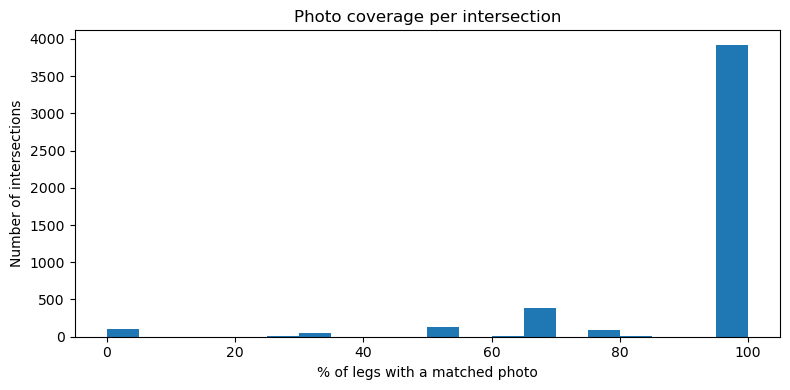

In [51]:
# Count how many legs per intersection have a matched photo
legs_per_inter    = legs_df.groupby("intersection_id").size().rename("total_legs")
matched_per_inter = result_df.groupby("intersection_id").size().rename("matched_legs")

coverage = pd.concat([legs_per_inter, matched_per_inter], axis=1).fillna(0)
coverage["matched_legs"] = coverage["matched_legs"].astype(int)
coverage["coverage_pct"] = (coverage["matched_legs"] / coverage["total_legs"] * 100).round(1)

print("Coverage summary:")
print(coverage["coverage_pct"].describe())
print(f"\nIntersections with all legs covered: {(coverage['coverage_pct']==100).sum():,}")
print(f"Intersections with no coverage:      {(coverage['matched_legs']==0).sum():,}")

# Histogram of coverage per intersection
fig, ax = plt.subplots(figsize=(8, 4))
coverage["coverage_pct"].plot.hist(bins=20, ax=ax)
ax.set_xlabel("% of legs with a matched photo")
ax.set_ylabel("Number of intersections")
ax.set_title("Photo coverage per intersection")
plt.tight_layout()
plt.show()

## 5. Visualise - spot check a single intersection

C:\Users\Thijs\AppData\Local\Temp\ipykernel_18632\3901129608.py:165: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(fontsize=8)


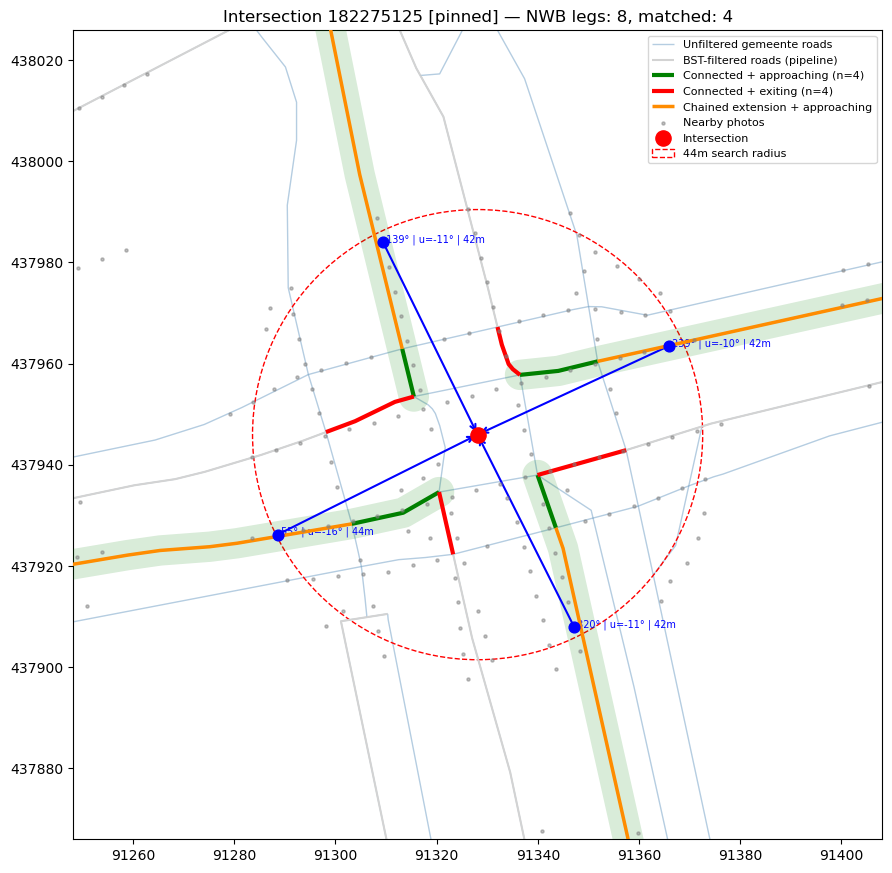

Intersection 182275125 [pinned] — matched photos:
 leg_bearing photo_filename  photo_dist_m  u_deg
       238.6      002_21339          41.8   -9.9
       138.7      002_17391          42.4  -10.9
       320.0      002_17068          42.5  -10.9
        54.7      002_21289          44.2  -16.3



C:\Users\Thijs\AppData\Local\Temp\ipykernel_18632\3901129608.py:165: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(fontsize=8)


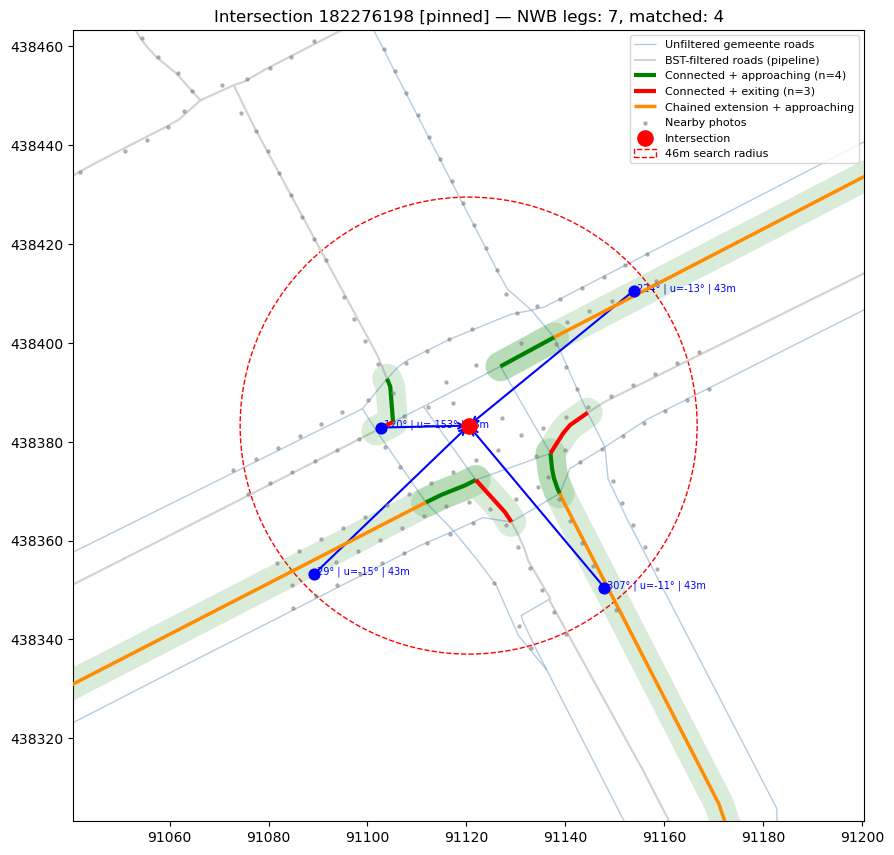

Intersection 182276198 [pinned] — matched photos:
 leg_bearing photo_filename  photo_dist_m  u_deg
       119.9      002_17178          17.6 -152.7
       306.6      002_17165          42.8  -11.2
       224.1      041_19765          43.1  -13.2
        29.1      002_17298          43.3  -14.8



C:\Users\Thijs\AppData\Local\Temp\ipykernel_18632\3901129608.py:165: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(fontsize=8)


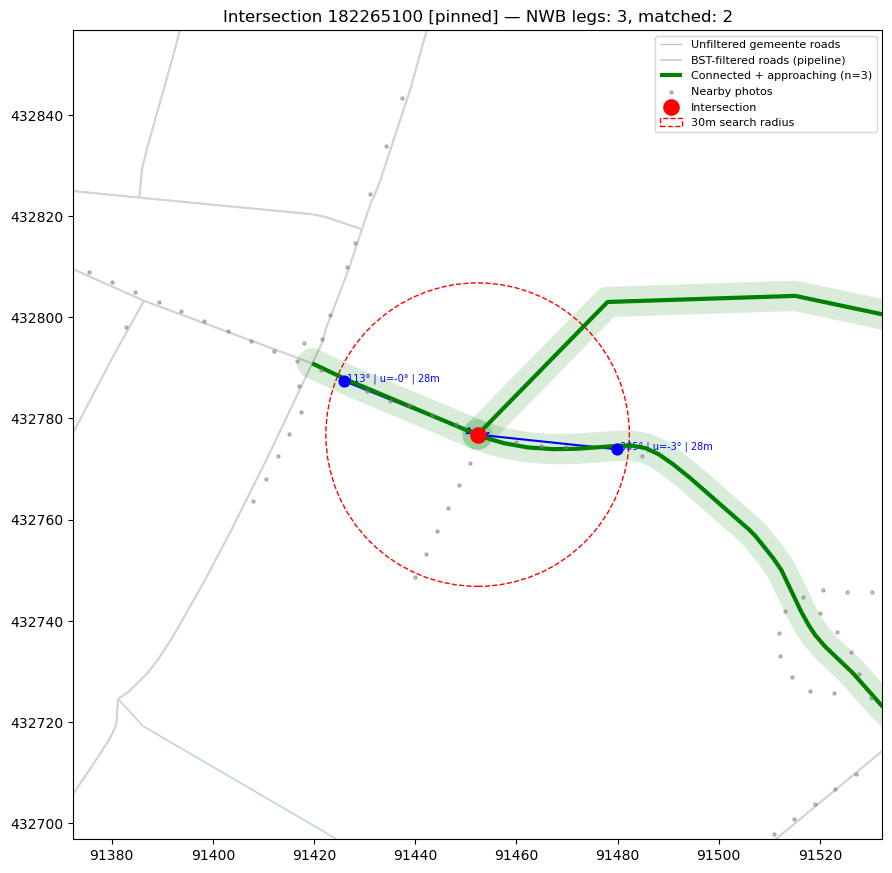

Intersection 182265100 [pinned] — matched photos:
 leg_bearing photo_filename  photo_dist_m  u_deg
       113.3      069_27796          28.5   -0.0
       304.7      069_27014          27.7   -3.1



C:\Users\Thijs\AppData\Local\Temp\ipykernel_18632\3901129608.py:165: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(fontsize=8)


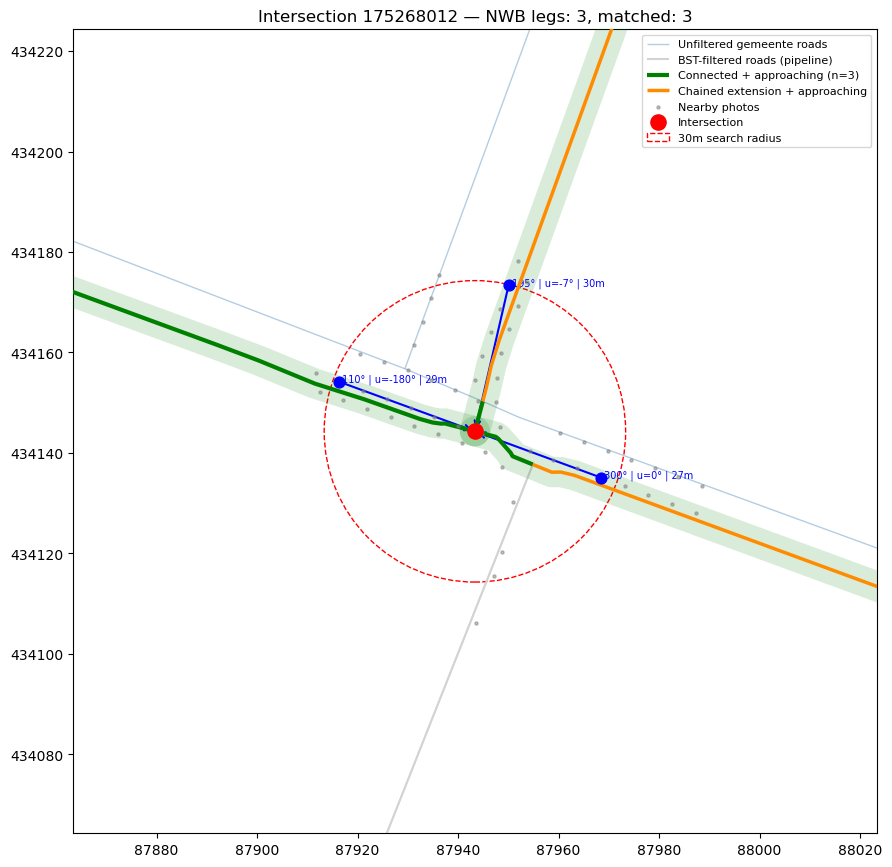

Intersection 175268012 — matched photos:
 leg_bearing photo_filename  photo_dist_m  u_deg
       194.7      071_12432          29.9   -7.1
       110.0      071_11454          28.7 -180.0
       299.8      071_11443          26.7    0.1



C:\Users\Thijs\AppData\Local\Temp\ipykernel_18632\3901129608.py:165: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(fontsize=8)


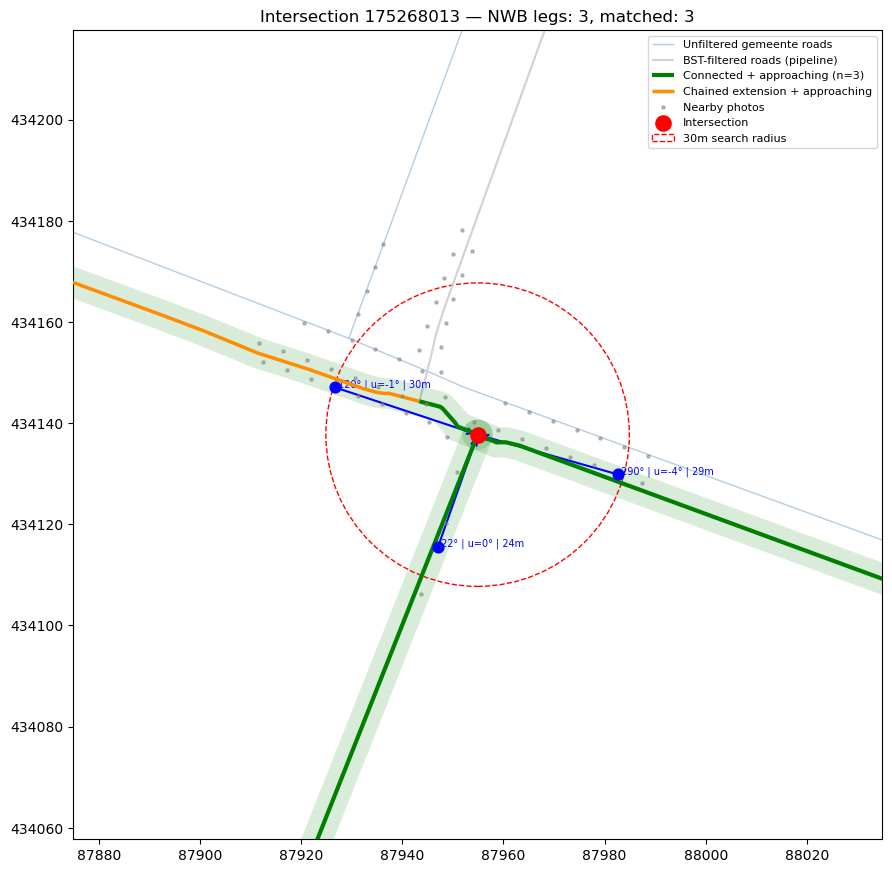

Intersection 175268013 — matched photos:
 leg_bearing photo_filename  photo_dist_m  u_deg
       119.8      071_11981          29.8   -1.0
       289.7      071_11440          28.8   -4.4
        21.6      071_12010          23.5    0.2



C:\Users\Thijs\AppData\Local\Temp\ipykernel_18632\3901129608.py:165: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(fontsize=8)


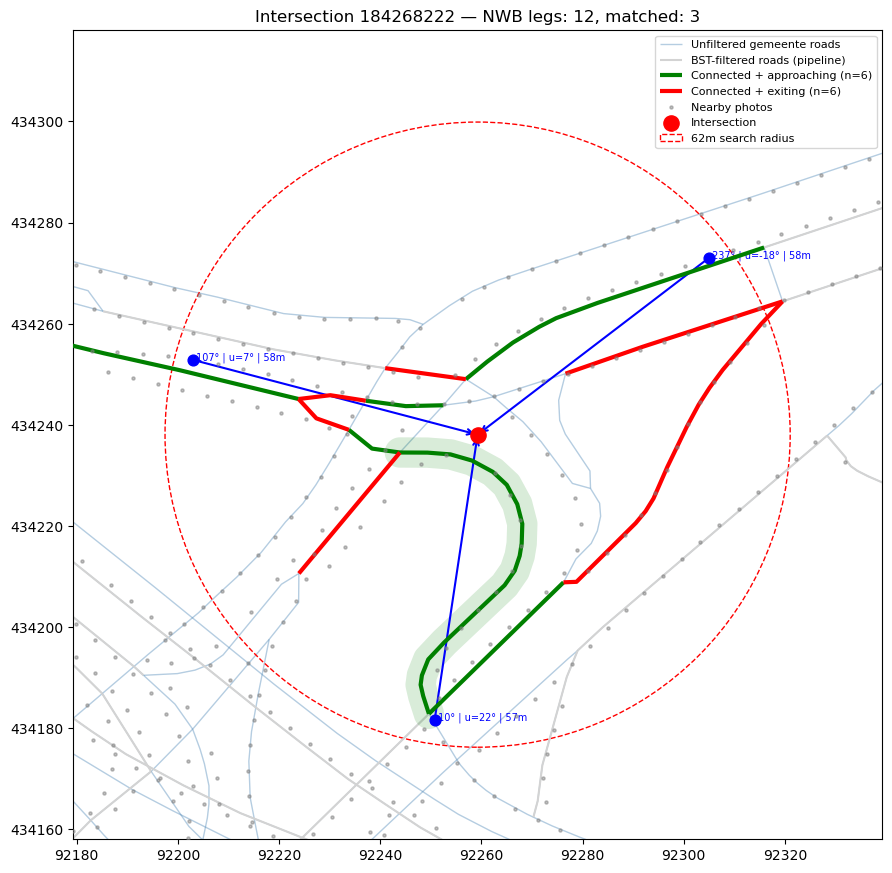

Intersection 184268222 — matched photos:
 leg_bearing photo_filename  photo_dist_m  u_deg
         9.9      004_12811          57.0   21.9
       236.8      004_19937          57.6  -17.9
       106.9      004_18254          58.2    7.1



C:\Users\Thijs\AppData\Local\Temp\ipykernel_18632\3901129608.py:165: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(fontsize=8)


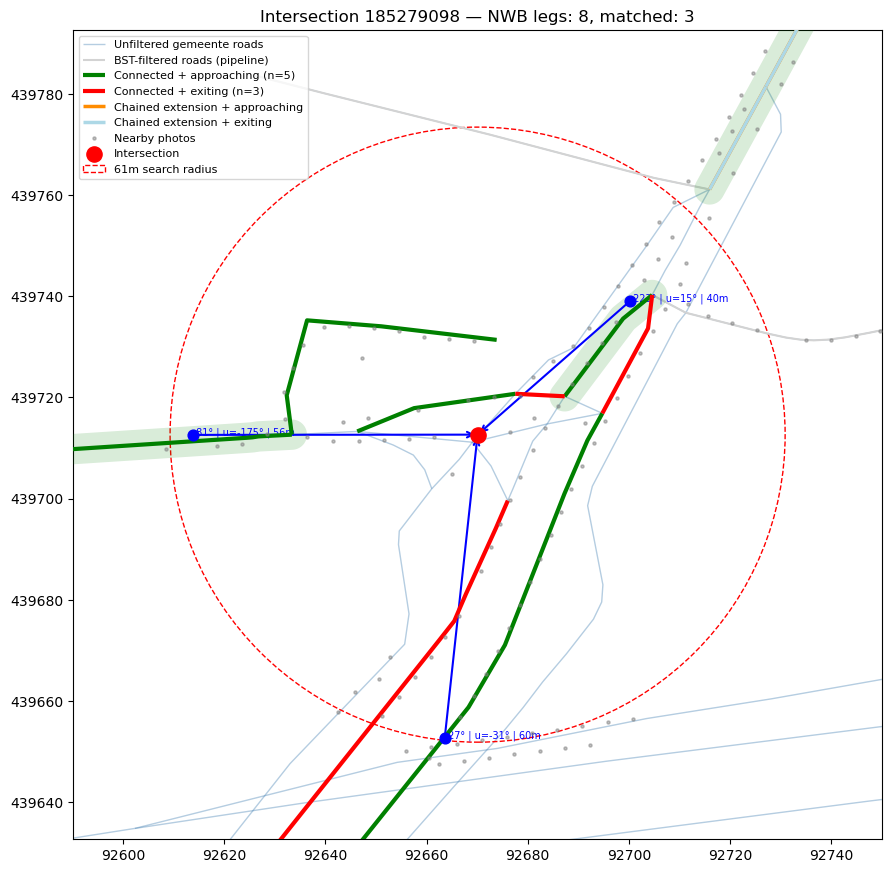

Intersection 185279098 — matched photos:
 leg_bearing photo_filename  photo_dist_m  u_deg
       222.7      067_15278          40.1   15.1
        81.1      067_13094          56.2 -174.8
        27.2      067_09420          60.3  -31.2



C:\Users\Thijs\AppData\Local\Temp\ipykernel_18632\3901129608.py:165: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(fontsize=8)


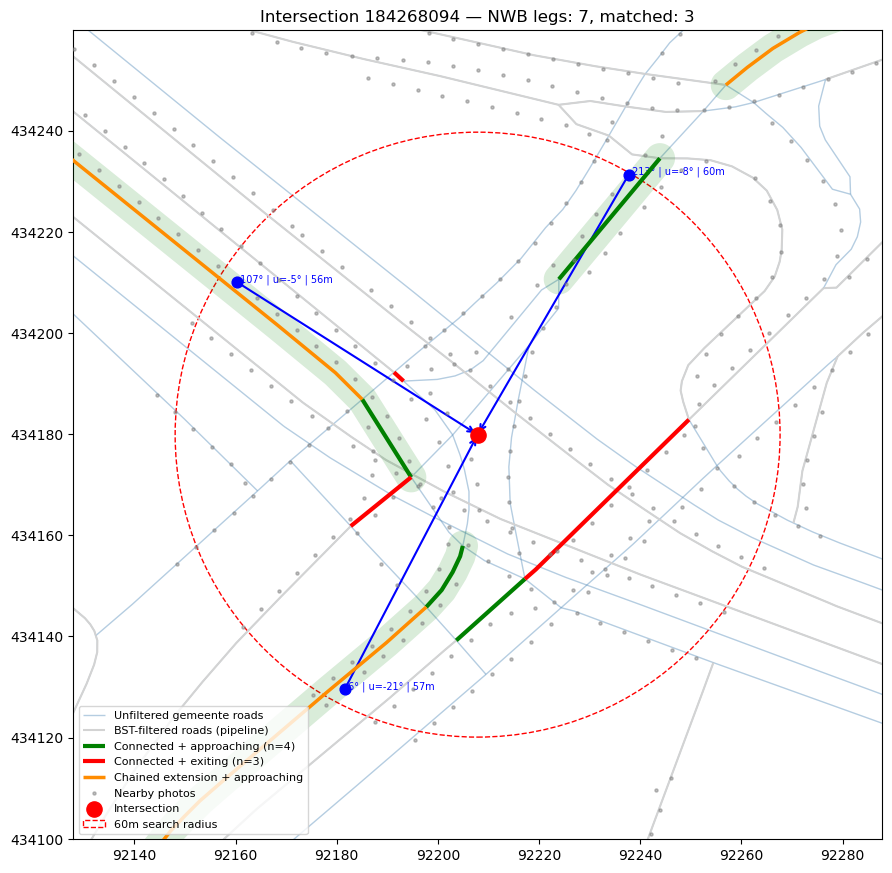

Intersection 184268094 — matched photos:
 leg_bearing photo_filename  photo_dist_m  u_deg
       107.0      002_16106          56.3   -5.3
         5.9      075_11750          56.7  -20.9
       213.4      004_19953          59.5   -8.2



In [52]:
import geopandas as gpd

# Always show these intersections first:
#   182275125 - the complex one used for initial debugging
#   182276198 - large multi-carriageway intersection (complex, many legs)
#   182265100 - curved approach legs, used to identify the chaining issue
# Then append up to 5 well-covered intersections as extra examples.
PINNED_IDS = [182275125, 182276198, 182265100]

well_covered = coverage[coverage["matched_legs"] >= 3].index

# Candidates: well-covered intersections not already pinned, with intersection metadata
wc_candidates = intersections.loc[
    [i for i in well_covered if i not in PINNED_IDS and i in intersections.index]
]

# 2 simplest (smallest diameter — singletons first)
simple_ids  = list(wc_candidates.nsmallest(2, "diameter_m").index)

# Up to 3 most complex (largest diameter), not already chosen as simple
complex_ids = list(
    wc_candidates[~wc_candidates.index.isin(simple_ids)]
    .nlargest(3, "diameter_m").index
)

extra_ids = simple_ids + complex_ids

# Only keep IDs that are actually in the processed set (in case N_INTERSECTIONS cut them off)
all_show_ids = [i for i in PINNED_IDS + extra_ids if i in intersections.index]

for example_id in all_show_ids:
    inter_row        = intersections.loc[example_id]
    inter_x, inter_y = inter_row.geometry.x, inter_row.geometry.y
    matched_legs_example = result_df[result_df["intersection_id"] == example_id]

    # Per-intersection search radius — used for the boundary circle in the plot
    search_radius = inter_row["max_dist_m"] if "max_dist_m" in inter_row.index else MAX_DIST

    # Photos within VIZ_RADIUS of the intersection
    nearby_mask = (
        (np.abs(photos_gdf["X/Long"] - inter_x) < VIZ_RADIUS) &
        (np.abs(photos_gdf["Y/Lat"]  - inter_y) < VIZ_RADIUS)
    )
    nearby_photos = photos_gdf[nearby_mask]

    # Bounding box mask for nearby road segments
    def nearby_wvk(gdf):
        b = gdf.geometry.bounds
        return gdf[
            (b["minx"] < inter_x + VIZ_RADIUS) & (b["maxx"] > inter_x - VIZ_RADIUS) &
            (b["miny"] < inter_y + VIZ_RADIUS) & (b["maxy"] > inter_y - VIZ_RADIUS)
        ]

    nearby_unfiltered = nearby_wvk(wegvakken_unfiltered)
    nearby_filtered   = nearby_wvk(wegvakken)

    # Directly connected segments (1st hop) with approach status merged in
    connected = wegvakken[
        (wegvakken["JTE_ID_BEG"] == example_id) |
        (wegvakken["JTE_ID_END"] == example_id)
    ]
    jte_status = (
        conn_approach[conn_approach["JTE_ID"] == example_id]
        [["WVK_ID", "approach_status"]]
        .drop_duplicates("WVK_ID")
    )
    connected_cl = connected.merge(jte_status, on="WVK_ID", how="left")
    connected_cl["approach_status"] = connected_cl["approach_status"].fillna("unknown")

    # Split directly connected segments by approach status for separate colouring
    conn_approaching = connected_cl[connected_cl["approach_status"] != "exiting"]
    conn_exiting     = connected_cl[connected_cl["approach_status"] == "exiting"]

    # For chained extensions, determine each leg's approach status by looking up
    # the directly connected segment that links example_id to neighbor_jte_id.
    # Chained geoms for approaching legs -> orange; for exiting legs -> light blue.
    # Buffers are only collected for approaching legs.
    legs_for_inter = legs_df[legs_df["intersection_id"] == example_id]

    orange_geoms    = []  # chained extension for an approaching leg
    lightblue_geoms = []  # chained extension for an exiting leg
    approaching_buffers = []

    for _, leg_row in legs_for_inter.iterrows():
        nbr_jte = leg_row["neighbor_jte_id"]

        # Find the WVK_ID(s) of the segment connecting example_id to neighbor_jte_id
        leg_wvk_ids = wegvakken[
            ((wegvakken["JTE_ID_BEG"] == example_id) & (wegvakken["JTE_ID_END"] == nbr_jte)) |
            ((wegvakken["JTE_ID_END"] == example_id) & (wegvakken["JTE_ID_BEG"] == nbr_jte))
        ]["WVK_ID"]

        # Look up approach status; default to 'unknown' if not found
        status_rows = jte_status[jte_status["WVK_ID"].isin(leg_wvk_ids)]
        leg_status  = status_rows.iloc[0]["approach_status"] if len(status_rows) > 0 else "unknown"
        is_approaching = leg_status != "exiting"

        # Collect buffer only for approaching legs
        if is_approaching:
            approaching_buffers.append(leg_row["road_buffer_geom"])

        # Collect chained geoms (those not already shown as directly connected)
        for geom in leg_row["chained_geoms"]:
            if not any(geom.equals(connected.geometry.iloc[i]) for i in range(len(connected))):
                if is_approaching:
                    orange_geoms.append(geom)
                else:
                    lightblue_geoms.append(geom)

    fig, ax = plt.subplots(figsize=(9, 9))

    # Layer 1: all gemeente roads before BST filter -- steelblue background context
    nearby_unfiltered.plot(ax=ax, color="steelblue", linewidth=1, alpha=0.4, zorder=1,
                           label="Unfiltered gemeente roads")
    # Layer 2: BST-filtered pipeline roads -- light grey
    nearby_filtered.plot(ax=ax, color="lightgrey", linewidth=1.5, zorder=2,
                         label="BST-filtered roads (pipeline)")
    # Layer 3: per-leg buffer polygons -- only for approaching legs (green tint)
    if approaching_buffers:
        buffers_gdf = gpd.GeoDataFrame(geometry=approaching_buffers, crs=CRS_RD)
        buffers_gdf.plot(ax=ax, color="green", alpha=0.15, zorder=3,
                         label=f"Approaching leg buffers ({ROAD_BUFFER_M}m)")
    # Layer 4a: directly connected + approaching -- solid green
    if len(conn_approaching) > 0:
        conn_approaching.plot(ax=ax, color="green", linewidth=3, zorder=4,
                              label=f"Connected + approaching (n={len(conn_approaching)})")
    # Layer 4b: directly connected + exiting -- solid red
    if len(conn_exiting) > 0:
        conn_exiting.plot(ax=ax, color="red", linewidth=3, zorder=4,
                          label=f"Connected + exiting (n={len(conn_exiting)})")
    # Layer 5a: chained extensions for approaching legs -- orange
    if orange_geoms:
        orange_gdf = gpd.GeoDataFrame(geometry=orange_geoms, crs=CRS_RD)
        orange_gdf.plot(ax=ax, color="darkorange", linewidth=2.5, zorder=5,
                        label=f"Chained extension + approaching")
    # Layer 5b: chained extensions for exiting legs -- light blue
    if lightblue_geoms:
        lb_gdf = gpd.GeoDataFrame(geometry=lightblue_geoms, crs=CRS_RD)
        lb_gdf.plot(ax=ax, color="lightblue", linewidth=2.5, zorder=5,
                    label=f"Chained extension + exiting")
    # Layer 6: all nearby photos as grey dots
    nearby_photos.plot(ax=ax, color="grey", markersize=5, alpha=0.5, zorder=6,
                       label="Nearby photos")
    # Layer 7: intersection centre -- red dot
    ax.scatter(inter_x, inter_y, color="red", s=120, zorder=7, label="Intersection")
    # Layer 8: matched leg photos -- blue dots with arrows and labels
    for _, leg in matched_legs_example.iterrows():
        ax.scatter(leg["photo_x"], leg["photo_y"], color="blue", s=60, zorder=8)
        ax.annotate("", xy=(inter_x, inter_y), xytext=(leg["photo_x"], leg["photo_y"]),
                    arrowprops=dict(arrowstyle="->", color="blue", lw=1.5))
        ax.text(leg["photo_x"], leg["photo_y"],
                f" {leg['leg_bearing']:.0f}° | u={leg['u_deg']:.0f}° | {leg['photo_dist_m']:.0f}m",
                fontsize=7, color="blue")

    # Search radius circle — per-intersection max_dist_m, not a fixed 55m
    circle = plt.Circle((inter_x, inter_y), search_radius, color="red", fill=False,
                         linestyle="--", linewidth=1,
                         label=f"{search_radius:.0f}m search radius")
    ax.add_patch(circle)

    tag = " [pinned]" if example_id in PINNED_IDS else ""
    ax.set_xlim(inter_x - VIZ_RADIUS, inter_x + VIZ_RADIUS)
    ax.set_ylim(inter_y - VIZ_RADIUS, inter_y + VIZ_RADIUS)
    ax.set_aspect("equal")
    ax.legend(fontsize=8)
    ax.set_title(
        f"Intersection {example_id}{tag} — "
        f"NWB legs: {len(connected)}, matched: {len(matched_legs_example)}"
    )
    plt.tight_layout()
    plt.show()

    print(f"Intersection {example_id}{tag} — matched photos:")
    print(matched_legs_example[["leg_bearing", "photo_filename", "photo_dist_m", "u_deg"]].to_string(index=False))
    print()

## 6. Export result

## 6a. Traffic intensity per approach leg

Adds `intensity_wvk` — the total daily traffic flow (vehicles/day) on the specific
road segment the photo was taken on. Unlike the intersection-level `intensity_sum`
(notebook 03), this is **per leg**: each approach can have a different intensity.

**Why per leg?** A T-junction may have a quiet residential street on one side and a
busy arterial on another. The intensity of the specific approach is more informative
for the safety assessment than the total over all legs.

**Source:** Fileradar AI model 2024 (`INTWERKP50`, weekday annual average).
The Rotterdam-only cache `intensiteiten_rotterdam.csv` is read here — it must exist
(run notebook 03 with `USE_INTENSITY=True` first).

**Join strategy:**
1. `legs_df.neighbor_jte_id` (junction at the far end of the approach) + `intersection_id`
   → match to `WVK_ID` in `wegvakken` via `JTE_ID_BEG` / `JTE_ID_END`
2. Look up `INTWERKP50` for that `WVK_ID` (H+T rows summed = total two-way flow)

**Output columns added to `leg_photo_selection.csv`:**
- `neighbor_jte_id` — far-end junction ID (identifies which road the photo is on)
- `WVK_ID` — NWB road segment ID of the approach
- `intensity_wvk` — vehicles/day on that segment (H+T combined)

In [ ]:
if USE_INTENSITY:
    if not os.path.exists(INTENSITY_ROT_FILE):
        raise FileNotFoundError(
            f"Intensity cache not found: {INTENSITY_ROT_FILE}\n"
            "Run notebook 03 first with USE_INTENSITY=True to generate the cache,\n"
            "or set USE_INTENSITY=False to skip this step."
        )

    # Load the Rotterdam intensity cache — one row per (WVK_ID, RIJRICHTNG).
    # This cache was created by notebook 03 from the full Zuid-Holland shapefile.
    int_cache = pd.read_csv(INTENSITY_ROT_FILE)
    int_cache = int_cache[int_cache["METHODE"] != "Geen"]   # drop sentinel -1 rows
    int_cache["WVK_ID_int"] = int_cache["WVK_ID"].astype(int)

    # Build total intensity per WVK_ID: sum INTWERKP50 across H and T rows.
    # For one-way roads (single row) this is the directional flow.
    # For two-way roads (two rows) this is the full bidirectional flow.
    wvk_intensity = (
        int_cache.groupby("WVK_ID_int")["INTWERKP50"]
        .sum()
        .to_dict()
    )
    print(f"WVK_IDs with valid intensity: {len(wvk_intensity):,}")

    # Add neighbor_jte_id from legs_df to result_df.
    # legs_df.neighbor_jte_id is the junction at the far end of the approach segment —
    # together with intersection_id it uniquely identifies which WVK connects this leg.
    result_df = result_df.merge(
        legs_df[["intersection_id", "leg_bearing", "neighbor_jte_id"]].drop_duplicates(),
        on=["intersection_id", "leg_bearing"],
        how="left"
    )

    # Find the WVK_ID for each leg by matching the junction pair in wegvakken.
    # A leg connects neighbor_jte_id → intersection_id; the segment in wegvakken
    # has one junction as JTE_ID_BEG and the other as JTE_ID_END.
    wvk_attrs = wegvakken[["WVK_ID", "JTE_ID_BEG", "JTE_ID_END"]].copy()

    # Case H: neighbor is at BEG, intersection is at END (H direction: BEG→END)
    match_h = result_df[["intersection_id", "leg_bearing", "neighbor_jte_id"]].merge(
        wvk_attrs.rename(columns={"JTE_ID_BEG": "neighbor_jte_id",
                                   "JTE_ID_END": "intersection_id"}),
        on=["intersection_id", "neighbor_jte_id"],
        how="inner"
    )

    # Case T: neighbor is at END, intersection is at BEG (T direction: END→BEG)
    match_t = result_df[["intersection_id", "leg_bearing", "neighbor_jte_id"]].merge(
        wvk_attrs.rename(columns={"JTE_ID_END": "neighbor_jte_id",
                                   "JTE_ID_BEG": "intersection_id"}),
        on=["intersection_id", "neighbor_jte_id"],
        how="inner"
    )

    # Combine both match directions, keep one WVK_ID per (intersection_id, leg_bearing).
    # H matches take priority since get_leg_bearings() already kept approaching H lanes.
    leg_to_wvk = (
        pd.concat([match_h, match_t])
        .drop_duplicates(subset=["intersection_id", "leg_bearing"])
        [["intersection_id", "leg_bearing", "WVK_ID"]]
    )

    result_df = result_df.merge(leg_to_wvk, on=["intersection_id", "leg_bearing"], how="left")

    # Look up intensity for each approach segment.
    # NaN is used when the WVK_ID is missing (no match) or not in the intensity data.
    result_df["intensity_wvk"] = result_df["WVK_ID"].map(
        lambda wid: wvk_intensity.get(int(wid), np.nan) if pd.notna(wid) else np.nan
    )

    n_matched = result_df["intensity_wvk"].notna().sum()
    print(f"Legs with intensity_wvk  : {n_matched:,} / {len(result_df):,}  ({n_matched/len(result_df)*100:.1f}%)")
    print(f"\nintensity_wvk stats (vehicles/day, H+T sum for this approach segment):")
    print(result_df["intensity_wvk"].describe().round(0))

else:
    # Add NaN columns so the output schema stays consistent regardless of the toggle
    result_df["neighbor_jte_id"] = np.nan
    result_df["WVK_ID"]          = np.nan
    result_df["intensity_wvk"]   = np.nan
    print("Traffic intensity skipped (USE_INTENSITY = False).")

## 7. Coverage check — photos in Recording.csv missing from the pre-filter

Notebook 02 pre-filtered Recording.csv to photos within 5–55m of intersections and wrote
`selected_photos_near_intersections.csv`. This section checks whether any photos that fall
inside that distance band were accidentally dropped.

`recording` is already loaded in section 1 with all columns. We use a KDTree on the
intersection coordinates for fast nearest-neighbour distance lookup across all ~700k photos.

In [ ]:
from scipy.spatial import KDTree

# --- Coverage check config ---
# Point this at the full photo index for whichever dataset you are using.
# This section is diagnostic only — it is not part of the pipeline output.
#   TU Delft 2024 : r"D:\rotterdam_aiis_2025\vault-production\vault_v1\image_index.csv"
#   Legacy AIIS   : r"D:\rotterdam_aiis_2025\vault-production\vault_v1\Recording.csv"
#                   (falls back to local copy if HDD not connected)
FULL_RECORDING_CSV = r"D:\rotterdam_aiis_2025\vault-production\vault_v1\image_index.csv"

# Load the full photo index — used only here to check for false drops
if FULL_RECORDING_CSV.endswith("image_index.csv"):
    recording = pd.read_csv(FULL_RECORDING_CSV).rename(columns={"image_id": "Filename"})
else:
    recording = pd.read_csv(FULL_RECORDING_CSV, sep="\t")
    recording.columns = recording.columns.str.strip()

# --- Step 1: identify photos in the full index not in the pre-filtered CSV ---
selected_filenames = set(selected["Filename"])
missing = recording[~recording["Filename"].isin(selected_filenames)].copy()

print(f"Total photos in full recording:                   {len(recording):,}")
print(f"Photos in selected_photos_near_intersections.csv: {len(selected_filenames):,}")
print(f"Photos in recording but NOT in selected:          {len(missing):,}")
print(f"  ({len(missing) / len(recording) * 100:.1f}% of all recordings were not pre-selected)")

# --- Step 2: fast nearest-intersection distance for every missing photo ---
inter_xy = np.column_stack([
    intersections.geometry.x.values,
    intersections.geometry.y.values,
])
tree = KDTree(inter_xy)

# Coordinate column names differ between datasets
x_col = "x" if "x" in missing.columns else "X/Long"
y_col = "y" if "y" in missing.columns else "Y/Lat"
missing_xy = missing[[x_col, y_col]].values

print("\nQuerying nearest-intersection distance for all missing photos...")
dists, nearest_idx = tree.query(missing_xy, k=1)

# --- Step 3: check for false drops ---
nearest_max_dist = intersections["max_dist_m"].values[nearest_idx]
in_nb04_range    = (dists >= MIN_DIST) & (dists <= nearest_max_dist)
n_false_drops    = in_nb04_range.sum()

print(f"\nMissing photos within notebook 04's per-intersection search range: {n_false_drops:,}")

if n_false_drops == 0:
    print("\nResult: no false drops detected.")
    print("Every photo notebook 04 could use is present in the pre-filtered CSV.")
else:
    false_drops = missing[in_nb04_range].copy()
    false_drops["dist_to_nearest_inter"] = dists[in_nb04_range]
    false_drops["nearest_inter_id"]      = intersections.index[nearest_idx[in_nb04_range]]
    false_drops["nearest_max_dist_m"]    = nearest_max_dist[in_nb04_range]

    print(f"\nWARNING: {n_false_drops:,} photos are within the per-intersection search range")
    print(f"but absent from the pre-filtered CSV — notebook 04 cannot find them.")
    print(f"\nDistance distribution of false drops (metres):")
    print(false_drops["dist_to_nearest_inter"].describe().round(1))
    print(f"\nSample rows:")
    print(
        false_drops[["Filename", x_col, y_col, "dist_to_nearest_inter",
                      "nearest_max_dist_m", "nearest_inter_id"]]
        .head(10)
        .to_string(index=False)
    )

# --- Step 4: intersection size distribution ---
print(f"\n--- Step 4: intersection size distribution ---")
print(f"max_dist_m range: {intersections['max_dist_m'].min():.1f}–{intersections['max_dist_m'].max():.1f}m")
oversized = intersections[intersections["max_dist_m"] > 55]
if len(oversized) > 0:
    oversized_legs = legs_df[legs_df["intersection_id"].isin(oversized.index)]
    unmatched_count = (
        oversized_legs
        .merge(
            result_df[["intersection_id", "leg_bearing"]].assign(_matched=True),
            on=["intersection_id", "leg_bearing"],
            how="left",
        )["_matched"]
        .isna()
        .sum()
    )
    print(f"Intersections with max_dist_m > 55m: {len(oversized):,} "
          f"(max: {oversized['max_dist_m'].max():.1f}m)")
    print(f"Affected legs: {len(oversized_legs):,} — unmatched among those: {unmatched_count:,}")
    if n_false_drops == 0:
        print("Notebook 02 covers these — no action needed.")
else:
    print("All intersections have max_dist_m <= 55m.")

In [ ]:
# Save the pipeline output: one best-matched photo per leg.
# This is consumed by notebooks 05, 06, and 07 -- schema must stay stable.
result_df.to_csv(OUTPUT_CSV, index=False)
print(f"Saved {len(result_df):,} leg-photo assignments to:")
print(f"  {OUTPUT_CSV}")

# Save the CV export list: top-N ranked candidates per leg (before bearing dedup).
# Each row has a candidate_rank column (1=best, 2=runner-up, ...) so downstream
# code can filter to any desired depth.
candidates_df = pd.DataFrame(all_candidates)
candidates_df.to_csv(CANDIDATES_CSV, index=False)
print(f"\nSaved {len(candidates_df):,} candidate rows (top-{TOP_N_CANDIDATES} per leg) to:")
print(f"  {CANDIDATES_CSV}")
print(f"  rank 1 : {(candidates_df['candidate_rank']==1).sum():,} legs")
print(f"  rank 2 : {(candidates_df['candidate_rank']==2).sum():,} legs")
print(f"  rank 3+: {(candidates_df['candidate_rank']>=3).sum():,} legs")

# Save log of directional images that were selected but not found on disk.
# Use this CSV to copy the missing files to the HDD and re-run notebook 07.
missing_df = pd.DataFrame(missing_files_log)
if len(missing_df) > 0:
    missing_df.to_csv(MISSING_FILES_CSV, index=False)
    print(f"\nWARNING: {len(missing_df):,} selected image files were not found on disk.")
    print(f"  Saved to: {MISSING_FILES_CSV}")
    print(f"  Copy the missing files to the HDD, then re-run notebook 07.")
    print(f"\n  Missing by direction:")
    print(missing_df["selected_direction"].value_counts().to_string())
else:
    print(f"\nAll selected image files found on disk — no missing files.")

result_df.head()